# Test

In [5]:
import os

import h5py
import matplotlib.pyplot as plt
import pandas as pd
import torch

import numpy as np

from PIL import Image
from tqdm import tqdm
from tools.utils import *
from model.SC_head import MulTaskHead


# load backbone model: gigapath

In [2]:
from torchvision import transforms
from model._factory import create_model

prov_gigapath_transform = transforms.Compose(
    [
        transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
        # transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

backbone = create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=False,
                         json_path="D:/Deeplearning_weights/prov-gigapath/config.json").to(device)
backbone_pretrain_path = "D:/Deeplearning_weights/prov-gigapath/pytorch_model.bin"
backbone_pretrain_weights = torch.load(backbone_pretrain_path)
backbone.load_state_dict(backbone_pretrain_weights)
backbone.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1536, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1536, out_features=4608, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1536, out_features=1536, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
      (mlp): GluMlp(
        (fc1): Linear(in_features=1536, out_features=8192, bias=True)
        (act): SiLU()
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
    

# load head

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seg_head = MulTaskHead().to(device)

weight_path = "weight/best.pth"

weight = torch.load(weight_path, map_location=lambda storage, loc: storage)
seg_head.load_state_dict(weight)
seg_head.eval()

MulTaskHead(
  (seg_head): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Dropout(p=0.25, inplace=False)
    (2): Conv2d(1536, 768, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(768, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Upsample(scale_factor=2.0, mode='nearest')
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(384, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): Upsample(scale_factor=2.0, mode='nearest')
    (10): Dropout(p=0.25, inplace=False)
    (11): Conv2d(192, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (layer1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): Dropout(p=0.25, inplace=False)
  )
  (attention_gate): Sequential(
    (0): Linear(in_features=12544, out_features=1536, bias=False)
    (1): Tanh()
  )
  (cls_hea

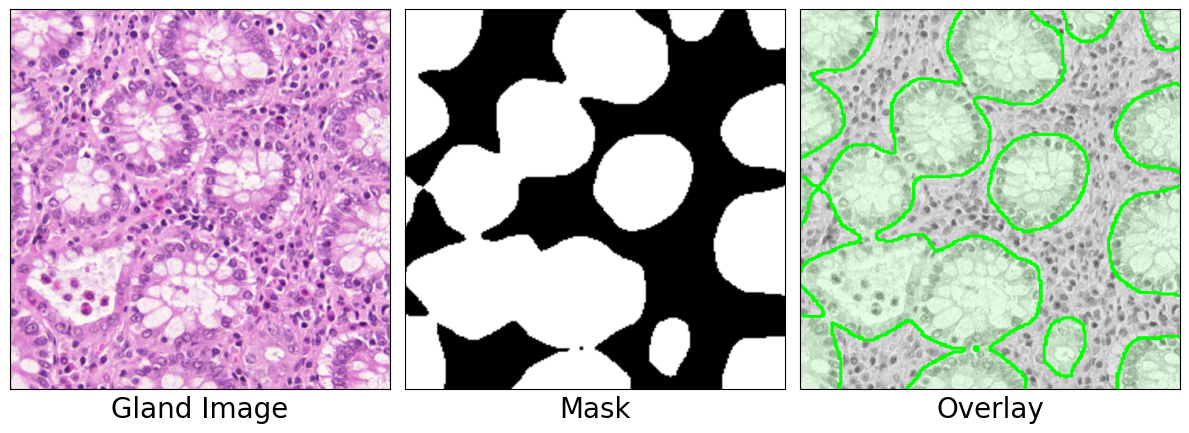

In [24]:
from matplotlib.lines import Line2D
def inference_image(feats, net):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    b_feats = torch.from_numpy(feats).unsqueeze(0)

    output, _ = net(b_feats.to(device))
    prob = torch.softmax(output, dim=1)
    predicted = torch.where(prob[:, 1, :, :] > 0.5, True, False)
    mask = predicted.squeeze().cpu().numpy()
    mask = mask.astype(np.uint8)
    return mask


original_image = Image.open('Image/0_testA_19.bmp')
original_np_img = np.array(original_image)

repeat_channel = (lambda x: np.repeat(x, 3, axis=-1))

img_tensor = prov_gigapath_transform(original_image)
img_tensor = img_tensor.unsqueeze(0).to(device)
feats = backbone.forward_features(img_tensor)
feats = np.array(np.array(feats.cpu().detach()))

mask = inference_image(feats, seg_head)
mask = mask * 255
mask = repeat_channel(mask[:, :, np.newaxis])
pil_mask = Image.fromarray(mask).resize(original_image.size)
final_mask = np.array(pil_mask)
pred_overlay_img = overlay_boundary(overlay_mask(original_np_img, final_mask, alpha=0.1),
                                                  final_mask)
imgs = [original_np_img, final_mask, pred_overlay_img]
captions = ['Gland Image', 'Mask', 'Overlay']
plot_comparison(imgs, captions, n_col=len(imgs), figsize=(12, 12), cmap=None,
                              plot=True)
# img.show()

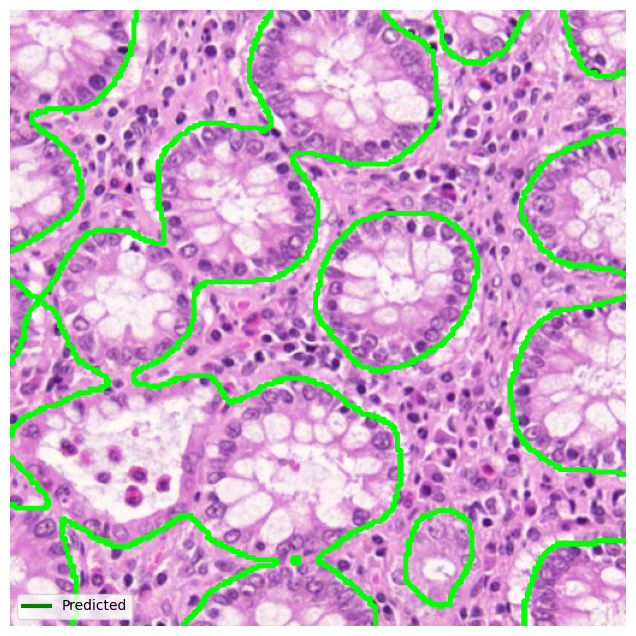

In [27]:

legend_elements = [Line2D([0], [0], color='g', lw=3, label='Predicted')]
ori_boundary_img = overlay_boundary(original_np_img, final_mask)
# supervimposed predicted boundary on ori boundary 
pred_boundary_img = overlay_boundary(ori_boundary_img, final_mask)
plt.figure(figsize=(8, 8))
plt.imshow(ori_boundary_img)
plt.legend(handles=legend_elements, loc='lower left')
plt.axis('off')
plt.show()
# plt.imshow(pred_boundary_img)
# plt.legend(handles=legend_elements, loc='lower left')
# plt.show()


In [41]:
# status = ['正常腺体', '正常组织', '低分化', '中度至轻度差异', '中度分化']

In [42]:
status = {'3_testA_10.bmp':'正常腺体', '0_testA_19.bmp':'正常组织', '3_testA_12.bmp':'低分化', '2_testA_22.bmp':'中度至轻度差异', '1_testA_13.bmp':'中度分化'}

In [44]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签SimHei
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

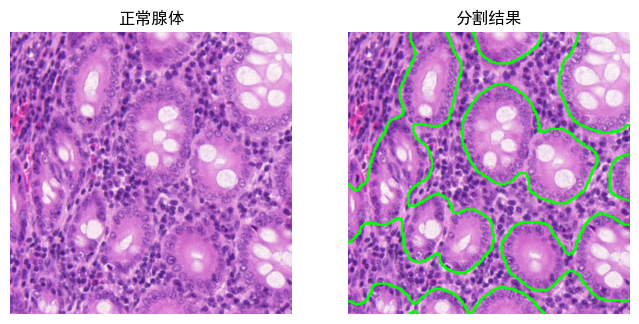

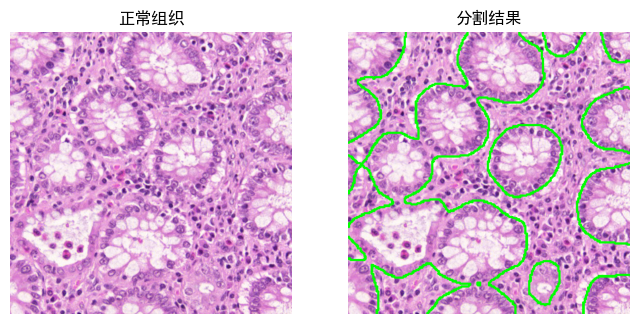

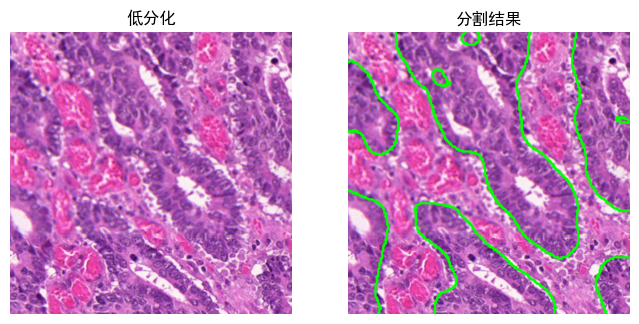

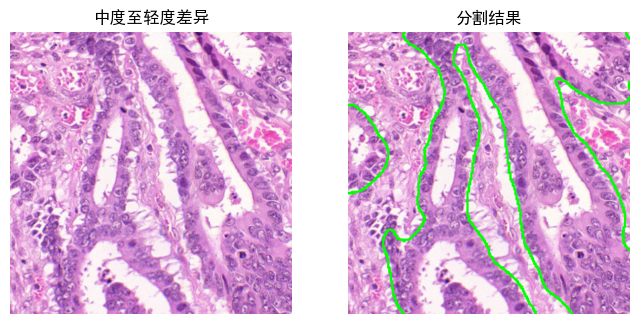

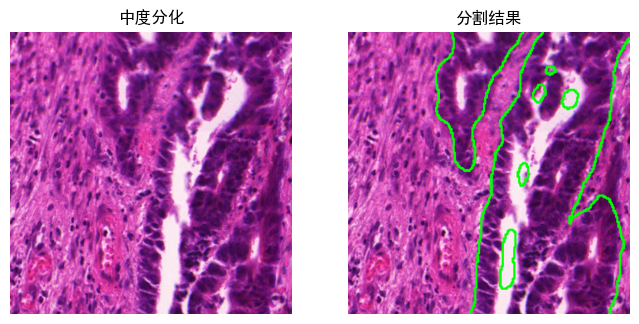

In [54]:
img_path = 'Image'
for name in status.keys():
    path = os.path.join(img_path, name)
    original_image = Image.open(path)
    original_np_img = np.array(original_image)
    
    repeat_channel = (lambda x: np.repeat(x, 3, axis=-1))
    
    img_tensor = prov_gigapath_transform(original_image)
    img_tensor = img_tensor.unsqueeze(0).to(device)
    feats = backbone.forward_features(img_tensor)
    feats = np.array(np.array(feats.cpu().detach()))
    
    mask = inference_image(feats, seg_head)
    mask = mask * 255
    mask = repeat_channel(mask[:, :, np.newaxis])
    pil_mask = Image.fromarray(mask).resize(original_image.size)
    final_mask = np.array(pil_mask)
    legend_elements = [Line2D([0], [0], color='g', lw=3, label='Predicted')]
    ori_boundary_img = overlay_boundary(original_np_img, final_mask)
    # supervimposed predicted boundary on ori boundary 
    fig, axs = plt.subplots(1, 2, figsize=(8, 5))
    # axs.title('111')
    axs[0].imshow(original_image)
    axs[0].axis('off')
    axs[0].set_title(status[name])
    axs[1].imshow(ori_boundary_img)
    axs[1].axis('off')
    axs[1].set_title('分割结果')
    # plt.imshow(ori_boundary_img)
    # plt.legend(handles=legend_elements, loc='lower left')
    # plt.axis('off')
    # imgs = [original_np_img,  ori_boundary_img]
    # captions = ['Gland Image', 'Overlay']
    # plot_comparison(imgs, captions, n_col=len(imgs), figsize=(12, 12), cmap=None,
    #                               plot=True)
    plt.margins(0, 0)
    plt.savefig(os.path.join('output', name.split('.')[0] + '.png'),bbox_inches='tight', pad_inches=0)
    # plt.title('111')
    # plt.show()

